<a href="https://colab.research.google.com/github/lilianabs/ml-algorithms-from-scratch/blob/main/Linear_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

# Generate a synthetic dataset for linear regression
X, y = make_regression(n_samples=100, n_features=4, noise=10, random_state=42)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 4)
Shape of y: (100,)


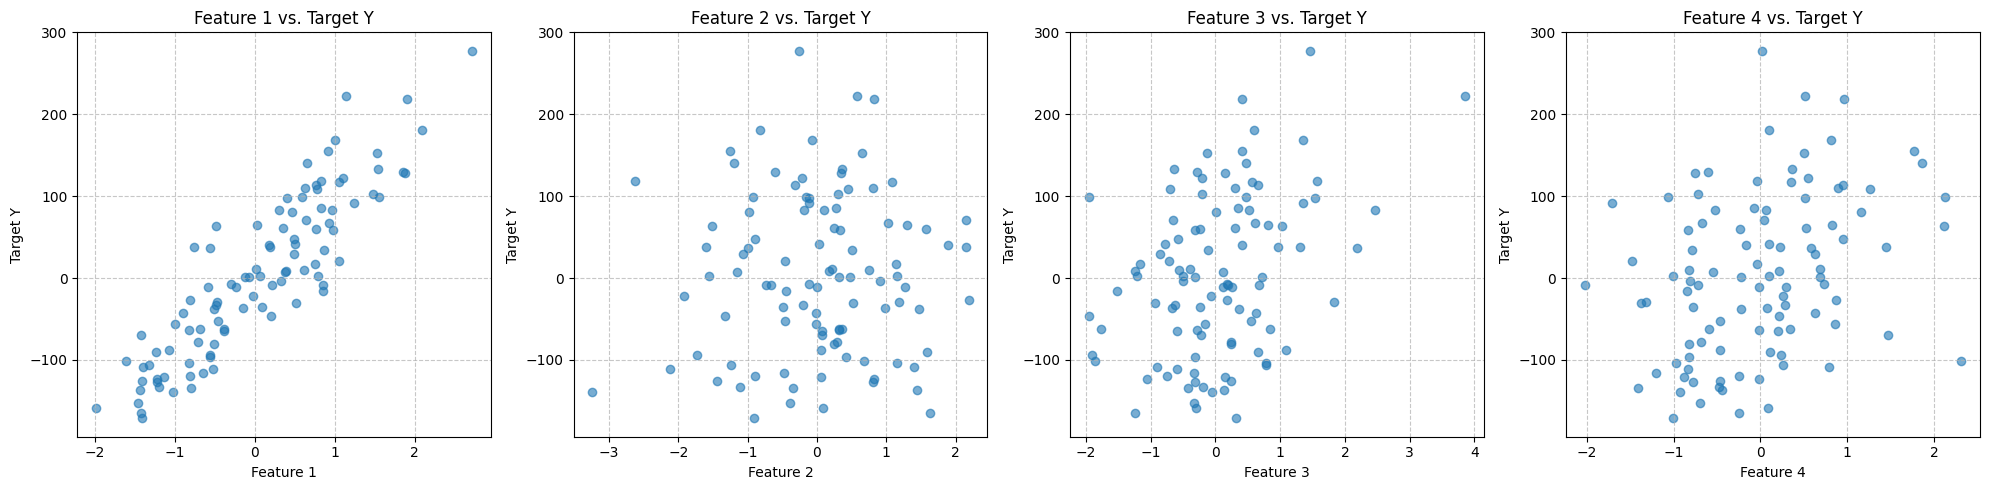

In [25]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
# Adjust figsize based on the number of features to ensure readability
fig, axes = plt.subplots(1, X.shape[1], figsize=(5 * X.shape[1], 5))

# If there's only one feature, axes will not be an array, so convert it to a list for consistent iteration
if X.shape[1] == 1:
    axes = [axes]

for i in range(X.shape[1]):
    axes[i].scatter(X[:, i], y, alpha=0.6)
    axes[i].set_title(f'Feature {i+1} vs. Target Y')
    axes[i].set_xlabel(f'Feature {i+1}')
    axes[i].set_ylabel('Target Y')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Logistic regression implementation (only functions)

In [26]:
n_samples = X.shape[0]
n_features = X.shape[1]
weights = np.zeros((n_features, 1))
bias = 0

In [27]:
n_iterations = 1000
learning_rate = 0.01

In [28]:
def compute_cost(X, error, n_samples):
  return (1/n_samples) * np.sum(error**2)

In [29]:
cost_iteration = []
for i in range(n_iterations):

  # Compute predictions
  z = np.dot(X, weights) + bias

  # Compute error
  error = z - y
  cost_iteration.append(compute_cost(X, error, n_samples))

  dw = (1 / n_samples) * np.dot(X.T, error)
  db = (1 / n_samples) * np.sum(error)

  # Update weights and bias
  weights = weights - (learning_rate * dw)
  bias = bias - (learning_rate * db)

  if i % 100 == 0: # Print less frequently due to more iterations
     print(f"Cost after iteration {i}: {cost_iteration[i]}")

Cost after iteration 0: 960718.7238605538
Cost after iteration 100: 955821.9684305657
Cost after iteration 200: 955438.3162009203
Cost after iteration 300: 955388.4315978341
Cost after iteration 400: 955381.8264142257
Cost after iteration 500: 955380.9275602364
Cost after iteration 600: 955380.8001986918
Cost after iteration 700: 955380.7811122772
Cost after iteration 800: 955380.7780436648
Cost after iteration 900: 955380.7775106151


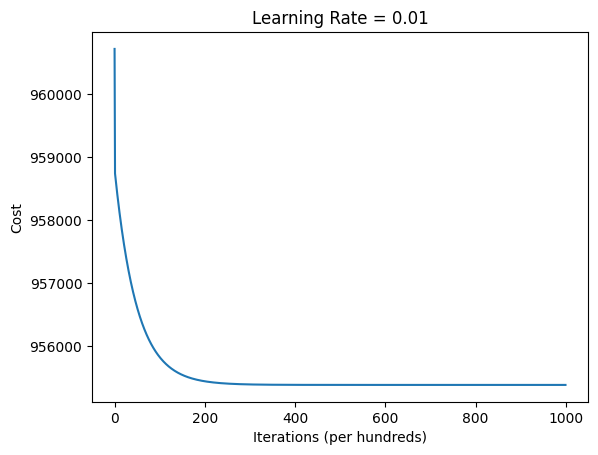

In [30]:
plt.plot(cost_iteration)
plt.ylabel('Cost')
plt.xlabel('Iterations (per hundreds)')
plt.title('Learning Rate = ' + str(learning_rate))
plt.show()